# Линейная регрессия

Линейная регрессия – один из самых простых и важных алгоритмов машинного обучения. Её идея – описать зависимость целевой
переменной от признаков линейной функцией и подобрать параметры так, чтобы предсказания были максимально близки к
наблюдениям.

Пусть у нас есть набор данных из \(N\) объектов: для каждого объекта известны признаки \(\mathbf{x}_i\) и целевое значение
\(y_i\). Мы хотим найти такую линейную функцию:

$$y = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

где:
- $\mathbf{w} = (w_1, w_2, \ldots, w_n)^T$ — вектор весов (параметров модели)
- $b$ — свободный член (bias)
- $\mathbf{x} = (x_1, x_2, \ldots, x_n)^T$ — вектор признаков объекта

![Бриллианты](../misc/images/diamonds.png)

Чтобы быстро перейти от теории к практике, возьмём реальный датасет о бриллиантах. Один из ключевых факторов цены –
каратность. Для начала предположим простую модель с одним признаком:

$$y = w \cdot x + b + \varepsilon$$

где:
- $y$ – цена бриллианта
- $x$ – каратность
- $b$ – базовая цена (свободный член)
- $w$ – «цена» одного карата (коэффициент при признаке)
- $\varepsilon$ – шум (то, что модель не объясняет)

Чтобы по каратности предсказывать цену для новых камней, нужно оценить параметры \(w\) и \(b\) по историческим данным.

Один из способов – аналитическое решение через метод наименьших квадратов (МНК). В матричной записи это приводит к
«нормальному уравнению»:

$$X^T (y - X\hat{w}) = 0$$

$$X^T X\hat{w} = {X}^T y$$

Если \(X^T X\) обратима, то:

$$\hat{w} = (X^T X)^{-1} X^T y$$


## Задание 1. Аналитическое решение

В этом задании ты реализуешь МНК «вручную», а затем проверишь себя с помощью `sklearn`.

1. **Подготовка данных:**
   - Загрузи датасет `diamonds.csv`.
   - Возьми один признак: каратность (`carat`) и целевую переменную: цену (`price`).
   - Сформируй матрицу признаков `X` размера \(N \times 1\) и вектор ответов `y` размера \(N\).

2. **Реализация аналитического решения (МНК):**
   - Добавь к `X` столбец единиц, чтобы учитывать свободный член \(b\).
   - Вычисли $$ \hat{w}\ $$ по формуле: $$ \hat{w} = (X^T X)^{-1} X^T y\ $$
   - Выведи полученные параметры модели: \(b\) и \(w\).

3. **Сравнение с `sklearn`:**
   - Обучи `LinearRegression` из `sklearn.linear_model` на тех же `X` и `y`.
   - Сравни коэффициенты: они должны совпасть или быть очень близкими (например, через `np.allclose`).

4. **Оценка качества и визуализация:**
   - Посчитай MAE (Mean Absolute Error, среднюю абсолютную ошибку) для аналитического решения.
   - Посчитай MAE для решения через `sklearn`.
   - Построй график: точки (реальные данные) и прямая регрессии (предсказания модели).

In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../production/AI_Machine_Learning.Project_3.ID_1577773/datasets/diamonds.csv")

In [3]:
X = df["carat"].values.reshape(-1, 1)
y = df["price"].values.reshape(-1, 1)

print(f"Размер данных: {X.shape[0]} образцов")
print(f"Диапазон carat: {X.min():.2f} - {X.max():.2f} карат")
print(f"Диапазон price: {y.min()} - {y.max()} долларов")

Размер данных: 53940 образцов
Диапазон carat: 0.20 - 5.01 карат
Диапазон price: 326 - 18823 долларов


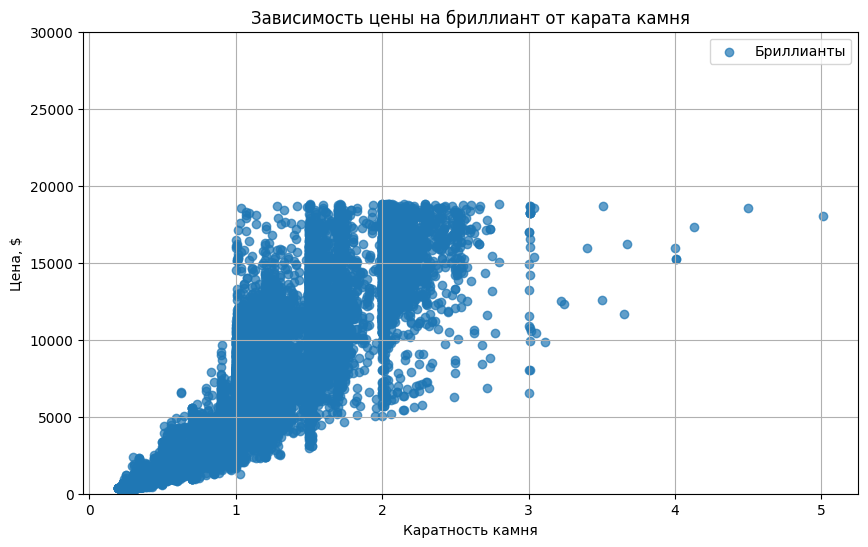

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label="Бриллианты")
plt.xlabel("Каратность камня")
plt.ylabel("Цена, $")
plt.title("Зависимость цены на бриллиант от карата камня")
plt.ylim(0, 30000)
plt.grid(True)
plt.legend()
plt.show()

In [5]:
X_b = np.c_[np.ones((len(X), 1)), X]  # Добавляем столбец единиц
w_analytic = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T.dot(y))

# Выводим параметры модели
b = w_analytic[0][0]
w = w_analytic[1][0]
print(f"Параметры модели:")
print(f"b (свободный член) = {b:.2f}")
print(f"w (коэффициент при carat) = {w:.2f}")

sklearn_model = LinearRegression()
sklearn_model.fit(X, y)

# Сравниваем коэффициенты
print(f"\nСравнение коэффициентов:")
print(f"Аналитическое решение: b = {b:.2f}, w = {w:.2f}")
print(f"sklearn: b = {sklearn_model.intercept_[0]:.2f}, w = {sklearn_model.coef_[0][0]:.2f}")
print(f"\nКоэффициенты совпадают: {np.allclose([b, w], [sklearn_model.intercept_[0], sklearn_model.coef_[0][0]])}")

y_pred = w_analytic[0] + w_analytic[1] * X
mae_analytic = mean_absolute_error(y, y_pred)

y_sklearn = sklearn_model.predict(X)
mae_sklearn = mean_absolute_error(y, y_sklearn)
print(f"\nMAE для аналитического решения: {mae_analytic:.2f}")
print(f"MAE для sklearn: {mae_sklearn:.2f}")

Параметры модели:
b (свободный член) = -2256.36
w (коэффициент при carat) = 7756.43

Сравнение коэффициентов:
Аналитическое решение: b = -2256.36, w = 7756.43
sklearn: b = -2256.36, w = 7756.43

Коэффициенты совпадают: True

MAE для аналитического решения: 1007.46
MAE для sklearn: 1007.46


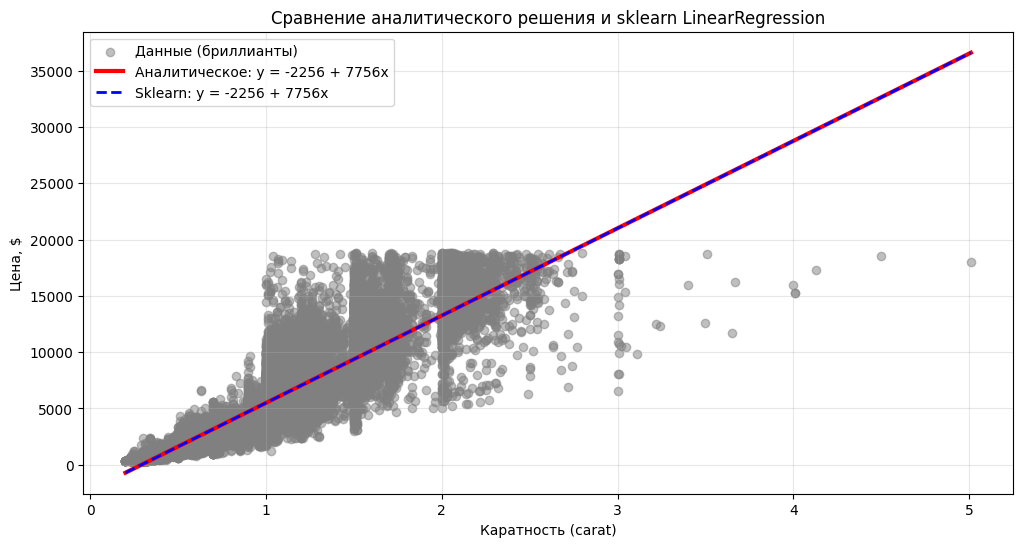

In [6]:
plt.figure(figsize=(12, 6))
plt.scatter(X, y, alpha=0.5, label='Данные (бриллианты)', color='gray')

x_range = np.array([[X.min()], [X.max()]])

# Аналитическое решение
y_analytic = w_analytic[0] + w_analytic[1] * x_range
plt.plot(x_range, y_analytic, 'r-', linewidth=3, 
         label=f'Аналитическое: y = {w_analytic[0][0]:.0f} + {w_analytic[1][0]:.0f}x')

# Sklearn решение
y_sklearn = sklearn_model.predict(x_range)
plt.plot(x_range, y_sklearn, 'b--', linewidth=2, 
         label=f'Sklearn: y = {sklearn_model.intercept_[0]:.0f} + {sklearn_model.coef_[0][0]:.0f}x')

plt.xlabel('Каратность (carat)')
plt.ylabel('Цена, $')
plt.title('Сравнение аналитического решения и sklearn LinearRegression')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Почему аналитическое решение не используется на практике?**

Основные проблемы:
- **Сложность вычислений**: $O(d^3)$, где $d$ — число признаков. Это становится невозможно вычислить для огромных датасетов.
- **Память**: Требуется хранить матрицу $X^TX$, что становится невозможным при большом $d$.
- **Численная нестабильность**: Матрица $X^TX$ может быть плохо обусловленной.

**Решение — градиентный спуск**

Градиентный спуск позволяет эффективно обучать модель даже на больших данных, избегая вычислительных и памяти затрат аналитического подхода.

Основная идея: мы хотим минимизировать функцию потерь — среднеквадратичную ошибку (MSE):

$$
L(w_0, w_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

где предсказание модели:

$$
\hat{y}_i = w_0 + w_1 x_{i1} + w_2 x_{i2} + \dots + w_d x_{id}
$$

или в компактной форме:

$$
\hat{y}_i = w_0 + w^\top x_i
$$

Для минимизации функции потерь мы будем использовать её **градиент**.

Градиент — это вектор, составленный из частных производных функции.  
Он показывает направление, в котором функция растёт быстрее всего.  
Поэтому, чтобы двигаться к минимуму, нам нужно идти в **противоположную** сторону — против градиента.

Следовательно, обновлять параметры будем по такому правилу:

$$
w_0 \leftarrow w_0 - \alpha \cdot \frac{\partial L}{\partial w_0}
$$

$$
w_j \leftarrow w_j - \alpha \cdot \frac{\partial L}{\partial w_j}, \quad j = 1, \dots, d
$$

где $\alpha$ — шаг (learning rate).

## Задание 2. Градиент функции потерь

Посчитай градиент функции потерь $L$ — частные производные по $w_0$ и $w_1$.  
Запиши:

$$
\frac{\partial L}{\partial w_0} = \dots
$$

$$
\frac{\partial L}{\partial w_1} = \dots
$$

## Задание 3. Обновление параметров

**Задачи:**
1. Напиши класс `Gradient()`, который при инициализации получает два вектора: `X`, `Y`. Класс должен содержать следующие методы:
   * `predict(w, b)`: принимает параметры `w`, `b`, возвращает прогнозные значения `Y_pred = w * X + b`
   * `mse(Y_pred)`: принимает предсказания `Y_pred`, возвращает среднеквадратичную ошибку относительно `Y`
   * `update(w, b, a=0.0001)`: принимает текущие параметры `w`, `b` и learning rate `a`, возвращает обновленные значения `w`, `b` согласно формулам градиентного спуска

2. Проверь работу методов:
   - Инициализируй класс с данными `X`, `Y` из ячейки ниже
   - Задай начальные параметры (например, `w=0`, `b=0`)
   - Вызови `predict` и `mse` для проверки
   - Вызови `update` несколько раз и визуализируй, как изменяется ошибка

3. **Визуализация процесса обучения:**
   - Создай функцию, которая принимает объект класса `Gradient`, начальные параметры и количество итераций
   - На каждой итерации записывай значение MSE
   - Построй график зависимости MSE от номера итерации
   - На том же графике отобрази исходные данные и линию регрессии на разных этапах обучения (начало, середина, конец)

In [7]:
class Gradient:
    def __init__(self, X, Y):
        self.X = np.asarray(X)
        self.Y = np.asarray(Y).flatten()
        self.N = len(self.Y)
        self.n_features = self.X.shape[1] if self.X.ndim > 1 else 1

    def predict(self, w, b):
        return self.X @ w + b

    def mse(self, Y_pred):
        return np.mean((self.Y - Y_pred) ** 2)

    def update(self, w, b, a=0.01):
        Y_pred = self.predict(w, b)
        errors = self.Y - Y_pred

        grad_w = -2 / self.N * (self.X.T @ errors)
        grad_b = -2 / self.N * np.sum(errors)

        w_new = w - a * grad_w
        b_new = b - a * grad_b

        return w_new, b_new

In [8]:
grad = Gradient(X, y)

w_init = np.zeros(X.shape[1])
b_init = 0.0

Y_pred_init = grad.predict(w_init, b_init)
mse_init = grad.mse(Y_pred_init)

In [9]:


def visualize_training(grad_obj, w_init, b_init, num_iterations, learning_rate):
    w = np.asarray(w_init).copy()
    b = float(b_init)
    
    mse_history = []
    w_history = []
    b_history = []
    
    # Начальное значение
    Y_pred = grad_obj.predict(w, b)
    mse = grad_obj.mse(Y_pred)
    mse_history.append(mse)
    w_history.append(w.copy())
    b_history.append(b)
    
    for i in range(num_iterations):
        w, b = grad_obj.update(w, b, a=learning_rate)
        Y_pred = grad_obj.predict(w, b)
        mse = grad_obj.mse(Y_pred)
        mse_history.append(mse)
        w_history.append(w.copy())
        b_history.append(b)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График MSE
    axes[0].plot(mse_history, 'b-', linewidth=2)
    axes[0].set_xlabel('Итерация')
    axes[0].set_ylabel('MSE')
    axes[0].set_title('Зависимость MSE от итерации')
    axes[0].grid(True, alpha=0.3)
    
    # График данных и линий регрессии (по первому признаку)
    axes[1].scatter(X[:, 0], y, alpha=0.6, s=50, label='Данные')
    
    x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 150)
    
    # Вспомогательная функция для вычисления линии
    def get_line(w_vec, b_val):
        if X.shape[1] == 1:
            return w_vec[0] * x_line + b_val
        else:
            # Средний вклад остальных признаков (приближённо)
            other_features_mean = X[:, 1:].mean(axis=0)
            other_contrib = np.dot(w_vec[1:], other_features_mean)
            return w_vec[0] * x_line + b_val + other_contrib
    
    # Начало
    y_line_init = get_line(w_history[0], b_history[0])
    axes[1].plot(x_line, y_line_init, 'r--', alpha=0.6, label='Начало')
    
    
    # Конец
    y_line_final = get_line(w_history[-1], b_history[-1])
    axes[1].plot(x_line, y_line_final, 'b-', lw=2.2,
                 label=f'Конец (ит. {len(w_history)-1})')
    
    axes[1].set_xlabel('Площадь')
    axes[1].set_ylabel('Цена')
    axes[1].set_title('Эволюция линии регрессии (по площади)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

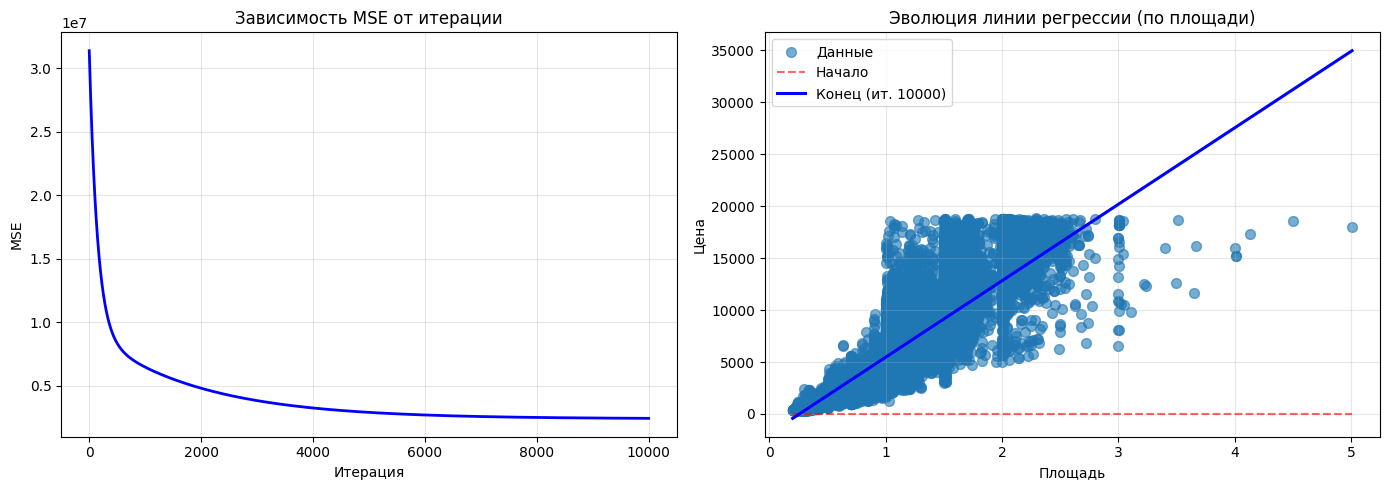

In [10]:
visualize_training(grad, w_init, b_init, 10000, 0.001)

## Задание 4. Градиентный спуск

Теперь мы готовы реализовать алгоритм [градиентного спуска](http://www.machinelearning.ru/wiki/index.php?title=%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%B3%D1%80%D0%B0%D0%B4%D0%B8%D0%B5%D0%BD%D1%82%D0%BD%D0%BE%D0%B3%D0%BE_%D1%81%D0%BF%D1%83%D1%81%D0%BA%D0%B0) с нуля.

Теперь создадим класс `GradientDescent`, который наследуется от `Gradient` и реализует полный цикл обучения.

**Задачи:**
1. Создай класс `GradientDescent(Gradient)`, который наследует все методы из `Gradient`
2. Добавь метод `optimize(num_iterations, stopping_threshold=0.001, a=0.000001, w_init=0, b_init=0)`:
   - Метод должен итеративно обновлять `w` и `b` с помощью метода `update`
   - Критерии остановки:
     * Превышено количество итераций `num_iterations`
     * Изменение MSE между итерациями меньше `stopping_threshold`
   - Метод должен вернуть словарь с ключами: `'w'`, `'b'`, `'mse'`, `'history'` (список значений MSE на каждой итерации), `'iterations'` (количество выполненных итераций)

3. **Визуализация и анализ:**
   - Обучи модель на данных `X`, `Y` с разными значениями learning rate: `[0.00001, 0.0001]`
   - Для каждого learning rate построй график зависимости MSE от номера итерации
   - На отдельном графике визуализируй финальные линии регрессии для разных learning rate
   - Сделай выводы: какой learning rate работает лучше? Что происходит при слишком большом/малом learning rate?

4. **Сравнение с аналитическим решением:**
   - Сравни полученные градиентным спуском значения с аналитическим решением
   - Визуализируй оба решения на одном графике

In [11]:
class GradientDescent(Gradient):
    def optimize(self, num_iterations=1000, stopping_threshold=1e-6, 
                 a=0.01, w_init=None, b_init=0.0):
        
        if w_init is None:
            w_init = np.zeros(self.n_features)
        else:
            w_init = np.asarray(w_init).flatten()[:self.n_features]
        w = np.asarray(w_init)
        b = float(b_init)
        
        history = []
        prev_mse = float('inf')
        
        for i in range(num_iterations):
            Y_pred = self.predict(w, b)
            mse = self.mse(Y_pred)
            history.append(mse)
            
            if i > 0 and abs(prev_mse - mse) < stopping_threshold:
                break
                
            w, b = self.update(w, b, a)
            prev_mse = mse
        
        return {
            'w': w,
            'b': b,
            'mse': self.mse(self.predict(w, b)),
            'history': history,
            'iterations': len(history)
        }


In [15]:
learning_rates = [0.01, 0.001]

results = {}
for lr in learning_rates:
    gd = GradientDescent(X, y)
    result = gd.optimize(num_iterations=10000, stopping_threshold=0.0001, a=lr, w_init=0, b_init=0)
    results[lr] = result

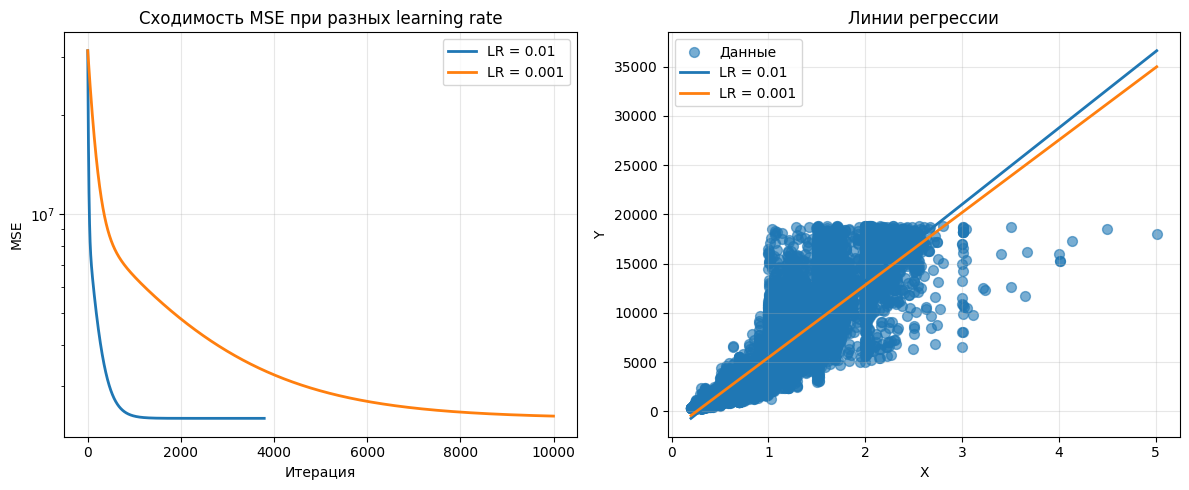

In [20]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for lr in learning_rates:
    history = results[lr]['history']
    plt.plot(history, label=f'LR = {lr}', linewidth=2)

plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость MSE при разных learning rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.6, label='Данные', s=50)

x_line = np.linspace(X.min(), X.max(), 100)
for lr in learning_rates:
    w = results[lr]['w']
    b = results[lr]['b']
    y_line = w * x_line + b
    plt.plot(x_line, y_line, label=f'LR = {lr}', linewidth=2)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Линии регрессии')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


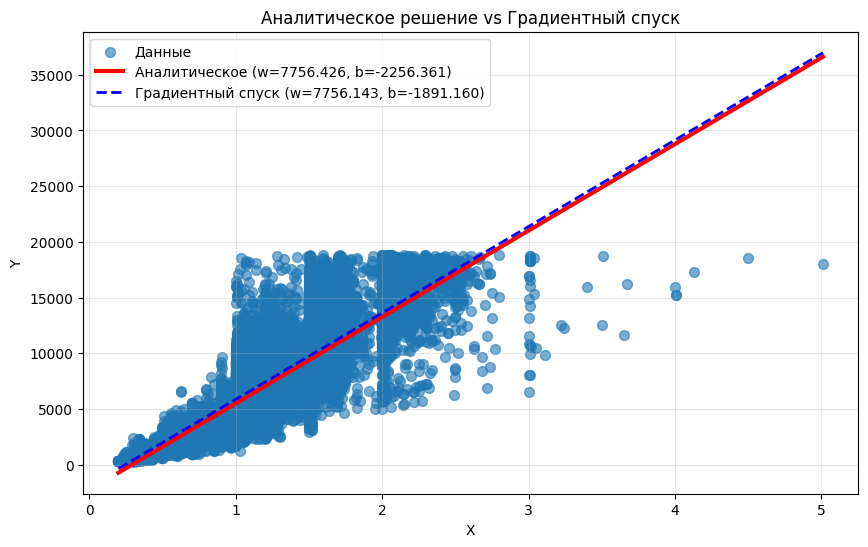

In [19]:
x_mean = np.mean(X)
y_mean = np.mean(y)
w_analytical = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean)**2)
b_analytical = y_mean - w_analytical * x_mean

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Данные', s=50)

x_line = np.linspace(X.min(), X.max(), 100)

# Аналитическое
y_analytical = w_analytical * x_line + b_analytical
plt.plot(x_line, y_analytical, 'r-', linewidth=3, 
         label=f'Аналитическое (w={w_analytical:.3f}, b={b_analytical:.3f})')

w_gd = results[0.01]['w']
b_gd = results[0.001]['b']
y_gd = w_gd * x_line + b_gd
plt.plot(x_line, y_gd, 'b--', linewidth=2, 
         label=f'Градиентный спуск (w={w_gd[0]:.3f}, b={b_gd:.3f})')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Аналитическое решение vs Градиентный спуск')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()